# Phase-2 heat maps

Two-dimensional (`delta`, `Delta`) sweeps built on top of the core notebook
(`phase2_multi_delta_core.ipynb`). Every stored timing pair is swept with no feasibility
filtering (`g_max = inf`, no trust floor, no Rician floor), matching section 2
of the core notebook.

**Run order:** this notebook needs every global the core notebook defines
(`analyze_acquisition`, the node table, `ACQUISITIONS`, etc). The first code
cell below loads them with `%run`. If your IPython build doesn't support
`%run` on a `.ipynb` (rare), just open `phase2_multi_delta_core.ipynb`, *Run All*, then run the
cells below in that same kernel instead.

After that, run the **registry cell** once. Then run **map A** and/or
**map B** as many times as you like, in any order — each run you name gets
stored, and you can point a later run's `..._COMPARE_TO` at an earlier name to
see exactly what changed.

## What you can adjust, at a glance

| Cell | Variable | What it does |
|---|---|---|
| registry | *(nothing to edit — shared infrastructure only)* | |
| map A / map B | `HMA_RHO/V/KIO` or `HMB_RHO/V/KIO` | which node (rho, V, k_io) the map is built at; defaults to the core notebook's `RHO, V, K_IO` |
| map A / map B | `HMA_B` / `HMB_B` | b-values (s/mm^2) carried by the swept timing |
| map A / map B | `HMA_METRIC` / `HMB_METRIC` | `"ratio"` (lambda3/lambda1, higher=better), `"crlb"`, or `"relative_crlb"` (both lower=better) |
| map A / map B | `HMA_PARAM` / `HMB_PARAM` | which parameter for the crlb metrics: 0=log_rho, 1=log_V, 2=k_io |
| map A / map B | `HMA_NAME` / `HMB_NAME` | name to store this run under in `HM_RUNS` (`""` = don't store) |
| map A / map B | `HMA_COMPARE_TO` / `HMB_COMPARE_TO` | an earlier run's name to diff against, or `None` |
| map A / map B | `HMA_CMP_MODE` / `HMB_CMP_MODE` | `"log2ratio"`, `"ratio"`, or `"diff"` for the comparison panel |
| map A / map B | `HMA_PANELS` / `HMB_PANELS` | `True` for 3 panels (reference, current, change), `False` for just the change panel |
| map A / map B | `HMA_LOG` / `HMB_LOG`, `..._VMIN`, `..._VMAX` | colour scale |
| map A / map B | `HMA_MARK_EXTREMA` / `HMB_MARK_EXTREMA` | star the min and max cell |
| map A only | `HMA_MARK_ACQ` | red `+` at the core notebook's `ACQUISITIONS` timings |
| map B only | `HMB_FIXED` | list of `(delta, Delta, [b-values])` rows held fixed in every cell |
| map B only | `HMB_NORM` | divide the map by the fixed-columns-alone value (1 = swept pair changed nothing) |

Useful registry helpers once the registry cell has run: `hm_list()` (what's
stored), `hm_get(name)`, `hm_drop(name)` (`"*"` clears everything).


/home/jaden/miniconda3/envs/mri/lib/python3.12/site-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)


COLUMN DOMAIN COMPLETE — all 31125 stored (delta, Delta, b) columns
11417 nodes | 1245 timing pairs x 25 b | n_ensembles=40
rho 1e+04..1e+07 cells/uL | V 0.01..200 pL | k_io 0..130 1/s
node 5311: rho=2.404e+05 cells/uL  V=3.357 pL  k_io=20 1/s  v_i=0.8071
4 acquisition columns, 4 kept by masks
  pair 201: delta=4.0, Delta=40.0 ms | b=[1000, 2500, 4000, 6000] | sigma=0.06008
steps: dlog(rho)=0.21979  dlog(V)=0.31458  dk_io=2.00000
  delta  Delta      b      G        S  keep |   J_logrho     J_logV       J_kio |  beta_rho    beta_V  beta_kio
---------------------------------------------------------------------------------------------------------------
    4.0   40.0   1000  0.150  0.36630  True |    0.35001    0.22134  -5.328e-03 |  6.31e-05  6.61e-05  3.52e-03
    4.0   40.0   2500  0.238  0.11815  True |    0.17581    0.07397  -3.617e-03 |  2.51e-04  5.29e-04  7.07e-03
    4.0   40.0   4000  0.301  0.04926  True |    0.08034    0.01725  -1.914e-03 |  8.56e-04  9.02e-03  2.12e-02
    4.

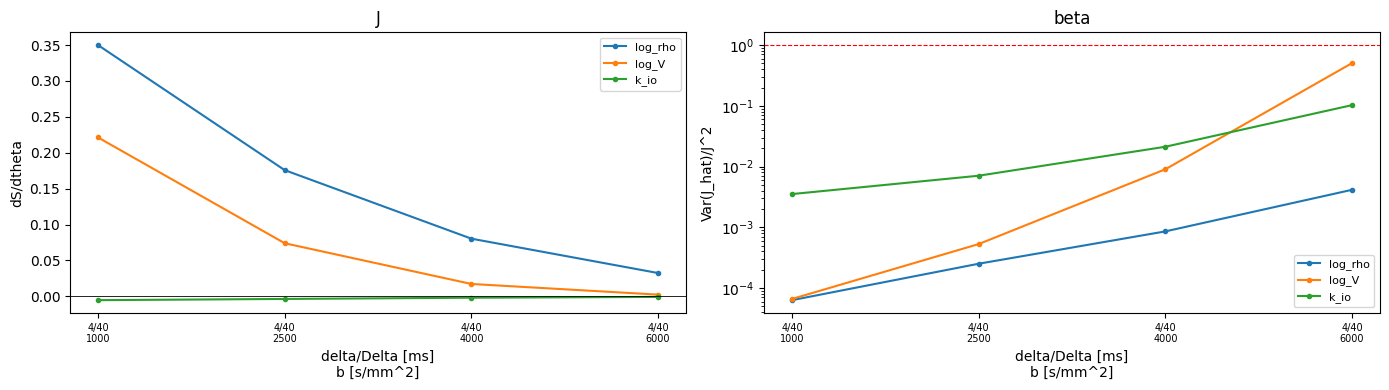

In [25]:
# Pull in everything the core notebook defines (node table, caches,
# analyze_acquisition, ACQUISITIONS, RHO/V/K_IO, ...) into this kernel.
%run "phase2_multi_delta_core.ipynb"

## Registry

Run this once. It defines `HM_RUNS` (the named-run store) and the shared
sweep/plot helpers used by both maps below. Safe to re-run after an edit —
your stored runs are kept, not wiped, and any run saved by an older version of
this cell is migrated automatically.

In [26]:
# ---- named run registry for the (Delta, delta) heat maps --------------------
# Run this cell once before the two map cells below. It holds the registry and
# the shared plot/compare helpers, so re-running a map cell never wipes your
# stored runs. Re-running THIS cell keeps the registry too (setdefault), so it
# is safe to re-execute after an edit.
#
# Each run picks one of three metrics (set HMA_METRIC / HMB_METRIC in the map
# cells):
#   "ratio"          lambda3/lambda1 of the k_io-scaled Fisher matrix, in
#                     (0, 1]. HIGHER is better (1 = perfectly balanced).
#   "crlb"            absolute Cramer-Rao bound of one parameter (PARAMETER_ORDER[param]).
#                     LOWER is better (smaller = more precise).
#   "relative_crlb"   fractional CRLB of that same parameter. LOWER is better.
# param picks which parameter for "crlb"/"relative_crlb": 0=log_rho, 1=log_V,
# 2=k_io. Ignored for "ratio".

import time

HM_CONVENTION = "lambda3/lambda1"                 # fallback label for pre-metric records
HM_SCHEMA = 2                                      # bumped: records now carry a metric


def hm_metric_label(metric, param):
    """Human-readable name + whether higher is better, for one metric/param pick."""
    if metric == "ratio":
        return "lambda3/lambda1", True
    pname = PARAMETER_ORDER[param]
    return (f"CRLB({pname})" if metric == "crlb" else f"relative CRLB({pname})"), False


def _hm_repair(rec, key):
    """Bring a record up to the current schema, or return None if it can't be.

    Records left in the kernel by an earlier version of these cells are missing
    newer keys. Anything that still carries a grid and a field array is filled
    in and kept; anything else is quarantined rather than silently dropped.
    Pre-metric records only ever held the lambda3/lambda1 ratio, so they are
    tagged as metric="ratio", higher_is_better=True.
    """
    if not isinstance(rec, dict) or not {"delta", "Delta"} <= set(rec):
        return None
    if "field" not in rec and "ratio" not in rec:
        return None
    r = dict(rec)
    r.setdefault("field", r.get("ratio"))          # old key -> new key
    if r.get("field") is None:
        return None
    r.setdefault("name", key)
    r.setdefault("mode", "unknown")
    r.setdefault("metric", "ratio")
    r.setdefault("param", None)
    r.setdefault("convention", HM_CONVENTION)
    r.setdefault("higher_is_better", True)          # true for every pre-metric record
    r.setdefault("node", -1)
    for k in ("rho", "V", "kio"):
        r.setdefault(k, np.nan)
    r.setdefault("b", [])
    r.setdefault("fixed", [])
    r.setdefault("lam", None)
    r.setdefault("settings", {})
    r.setdefault("stamp", "unknown")
    r["delta"] = np.asarray(r["delta"], float)
    r["Delta"] = np.asarray(r["Delta"], float)
    r["field"] = np.asarray(r["field"], float)
    r.pop("ratio", None)                            # superseded by "field"
    fin = int(np.isfinite(r["field"]).sum())
    r.setdefault("n_ok", fin)
    r.setdefault("n_notpd", None)                   # unknown for migrated records
    r.setdefault("n_missing", None)
    r["schema"] = HM_SCHEMA
    return r


# Carry over whatever is already in the kernel, repairing old-schema records.
_hm_prev = globals().get("HM_RUNS", {})
HM_RUNS = {}
HM_RUNS_INCOMPATIBLE = globals().get("HM_RUNS_INCOMPATIBLE", {})
_fixed_up, _quarantined = [], []
for _k, _v in (_hm_prev.items() if isinstance(_hm_prev, dict) else []):
    _r = _hm_repair(_v, _k)
    if _r is None:
        HM_RUNS_INCOMPATIBLE[_k] = _v
        _quarantined.append(_k)
    else:
        HM_RUNS[_k] = _r
        if _v.get("schema") != HM_SCHEMA:
            _fixed_up.append(_k)
if _fixed_up:
    print(f"migrated {len(_fixed_up)} older run(s) to the current schema: "
          + ", ".join(sorted(_fixed_up)))
if _quarantined:
    print(f"{len(_quarantined)} unreadable run(s) moved to HM_RUNS_INCOMPATIBLE: "
          + ", ".join(sorted(_quarantined)))
del _hm_prev, _fixed_up, _quarantined


def hm_record(name, mode, node, b, fixed, delta, Delta, field, lam, counts,
              metric="ratio", param=None):
    """Package one sweep into a registry record. Arrays are copied."""
    convention, higher_is_better = hm_metric_label(metric, param)
    return {
        "name": name, "mode": mode, "metric": metric, "param": param,
        "convention": convention, "higher_is_better": higher_is_better,
        "node": int(node),
        "rho": float(NODE_RHO[node]), "V": float(NODE_V[node]), "kio": float(NODE_KIO[node]),
        "b": list(b),
        "fixed": [(float(d), float(D), list(bb)) for d, D, bb in fixed],
        "delta": np.array(delta, float), "Delta": np.array(Delta, float),
        "field": np.array(field, float), "lam": np.array(lam, float),
        "n_ok": counts[0], "n_notpd": counts[1], "n_missing": counts[2],
        "settings": {"AVERAGES": AVERAGES, "SNR": SNR, "T2_MS": T2_MS,
                     "T_EPI_MS": T_EPI_MS, "DEBIAS": DEBIAS, "N0_EFF": N0_EFF,
                     "DROP_B0": DROP_B0, "g_max": np.inf,
                     "trust_floor": 0.0, "rician_min": 0.0},
        "stamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "schema": HM_SCHEMA,
    }


def hm_store(rec):
    """Put a record in the registry under rec['name']. Empty name = don't store."""
    name = rec["name"]
    if not name:
        print("run not stored (name is empty)")
        return
    verb = "replaced" if name in HM_RUNS else "stored"
    HM_RUNS[name] = rec
    print(f"run {verb} as '{name}'  ({len(HM_RUNS)} run(s) in HM_RUNS)")


def hm_get(name):
    """Fetch a record, with a useful error listing what is available."""
    if name not in HM_RUNS:
        have = ", ".join(sorted(HM_RUNS)) or "none"
        raise KeyError(f"no run named '{name}' in HM_RUNS. available: {have}")
    return HM_RUNS[name]


def hm_describe(rec, short=False):
    """One-line description of a run. Tolerant of missing keys."""
    fixed = rec.get("fixed") or []
    fx = ("none" if not fixed
          else " + ".join(f"{d:.0f}/{D:.0f}" for d, D, *_ in fixed))
    name, node, b = rec.get("name", "?"), rec.get("node", "?"), rec.get("b", [])
    if short:
        return f"{name} | node {node} | fixed {fx} | b {b}"
    rho, V, kio = rec.get("rho", np.nan), rec.get("V", np.nan), rec.get("kio", np.nan)
    return (f"{name}  [{rec.get('mode', 'unknown')}]\n"
            f"node {node} (rho={rho:.3g}, V={V:.3g}, k_io={kio:.3g})"
            f" | fixed delta/Delta: {fx} | swept b: {b}")


def hm_list():
    """Print the registry. A broken record is reported, not raised."""
    if not HM_RUNS:
        print("HM_RUNS is empty")
    else:
        print(f"{len(HM_RUNS)} run(s) in HM_RUNS:")
        for k in sorted(HM_RUNS):
            r = HM_RUNS[k]
            try:
                fin = np.isfinite(r["field"])
                med = np.nanmedian(r["field"][fin]) if fin.any() else np.nan
                cnt = " / ".join("?" if r.get(x) is None else str(r.get(x))
                                 for x in ("n_ok", "n_notpd", "n_missing"))
                print(f"  {hm_describe(r, short=True)} | median {med:.4g} | "
                      f"{cnt} ok/notPD/missing | {r.get('stamp', '?')}")
            except Exception as exc:                # never let one record hide the rest
                print(f"  {k} | unreadable ({type(exc).__name__}: {exc})")
    if HM_RUNS_INCOMPATIBLE:
        print(f"plus {len(HM_RUNS_INCOMPATIBLE)} quarantined in HM_RUNS_INCOMPATIBLE: "
              + ", ".join(sorted(HM_RUNS_INCOMPATIBLE)))


def hm_drop(name):
    """Remove one run, or pass '*' to clear the registry."""
    if name == "*":
        HM_RUNS.clear(); print("HM_RUNS cleared")
    else:
        HM_RUNS.pop(name, None); print(f"dropped '{name}'")


def _hm_check(cur, ref):
    """Guard the comparisons that would be meaningless or silently wrong."""
    if not (np.array_equal(cur["delta"], ref["delta"])
            and np.array_equal(cur["Delta"], ref["Delta"])):
        raise ValueError(f"grids differ between '{cur['name']}' and '{ref['name']}'; "
                         "both runs must sweep the same stored timing pairs")
    if cur.get("convention") != ref.get("convention"):
        raise ValueError(f"ratio convention differs: '{cur.get('name')}' is "
                         f"{cur.get('convention')}, '{ref.get('name')}' is "
                         f"{ref.get('convention')}")
    notes = []
    if cur.get("node") != ref.get("node"):
        notes.append(f"different parameter node ({ref.get('node')} -> {cur.get('node')})")
    if cur.get("mode") != ref.get("mode"):
        notes.append(f"different sweep mode ({ref.get('mode')} -> {cur.get('mode')})")
    _rs = ref.get("settings") or {}
    for k, v in (cur.get("settings") or {}).items():
        if _rs and _rs.get(k) != v:
            notes.append(f"{k}: {_rs.get(k)} -> {v}")
    if notes:
        print("note, these differ between the two runs (may be intentional):")
        for n in notes:
            print(f"  {n}")


def _edges(c):
    """Cell edges from (possibly non-uniform) centres."""
    c = np.asarray(c, float)
    if c.size == 1:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    m = 0.5 * (c[1:] + c[:-1])
    return np.concatenate(([2 * c[0] - m[0]], m, [2 * c[-1] - m[-1]]))


def _panel(ax, rec, field, cmap, norm_kw, label, title, marks=(), mark_extrema=True,
           diverging=False):
    pc = ax.pcolormesh(_edges(rec["Delta"]), _edges(rec["delta"]),
                       np.ma.masked_invalid(field), cmap=cmap, shading="flat", **norm_kw)
    lo = min(rec["delta"].min(), rec["Delta"].min())
    hi = max(rec["delta"].max(), rec["Delta"].max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=.8, alpha=.7)     # Delta = delta, reference only
    for d, D in marks:
        ax.plot(D, d, "r+", ms=11, mew=1.6)
    if mark_extrema and np.isfinite(field).any():
        i_min = np.unravel_index(np.nanargmin(field), field.shape)
        i_max = np.unravel_index(np.nanargmax(field), field.shape)
        ax.plot(rec["Delta"][i_min[1]], rec["delta"][i_min[0]], "*", color="deepskyblue",
                ms=17, mec="k", mew=1, label=f"min = {field[i_min]:.3g}")
        ax.plot(rec["Delta"][i_max[1]], rec["delta"][i_max[0]], "*", color="orange",
                ms=17, mec="k", mew=1, label=f"max = {field[i_max]:.3g}")
        ax.legend(loc="best", fontsize=7)
    ax.set(xlabel="Delta [ms]", ylabel="delta [ms]", title=title,
           xlim=(_edges(rec["Delta"])[0], _edges(rec["Delta"])[-1]),
           ylim=(_edges(rec["delta"])[0], _edges(rec["delta"])[-1]))
    ax.figure.colorbar(pc, ax=ax, label=label)


def hm_show(rec, ref=None, cmp_mode="log2ratio", log=True, vmin=None, vmax=None,
            marks=(), mark_extrema=True, panels=True, figsize=None):
    """Plot one run, or three panels (reference, current, change) when ref is given.

    cmp_mode: 'log2ratio' -> log2(current / reference), 0 = no change, +1 = doubled
              'ratio'     -> current / reference, 1 = no change
              'diff'      -> current - reference, 0 = no change
    The change panel is direction-neutral (red = current > reference, blue =
    current < reference). Whether bigger or smaller is actually better depends
    on the metric (ratio: higher is better; crlb/relative_crlb: lower is
    better) -- that direction is reported separately in the printed stats
    below the figure using each record's own "higher_is_better" flag.
    """
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("0.85")                                    # grey = no finite field

    if ref is None:
        f = np.log10(rec["field"]) if log else rec["field"]
        _cv = rec.get("convention", HM_CONVENTION)
        lbl = f"log10({_cv})" if log else _cv
        fig, ax = plt.subplots(figsize=figsize or (9, 6))
        _panel(ax, rec, f, cmap, dict(vmin=vmin, vmax=vmax), lbl, hm_describe(rec),
               marks, mark_extrema)
        fig.tight_layout()
        return fig

    _hm_check(rec, ref)
    both = np.concatenate([rec["field"][np.isfinite(rec["field"])],
                           ref["field"][np.isfinite(ref["field"])]])
    b_lo, b_hi = (np.log10(both.min()), np.log10(both.max())) if log and both.size \
        else (vmin, vmax)

    with np.errstate(divide="ignore", invalid="ignore"):
        if cmp_mode == "log2ratio":
            chg = np.log2(rec["field"] / ref["field"]); clbl = "log2(current / reference)"
        elif cmp_mode == "ratio":
            chg = rec["field"] / ref["field"]; clbl = "current / reference"
        elif cmp_mode == "diff":
            chg = rec["field"] - ref["field"]; clbl = "current - reference"
        else:
            raise ValueError("cmp_mode must be 'log2ratio', 'ratio' or 'diff'")
    chg[~np.isfinite(chg)] = np.nan

    centre = 1.0 if cmp_mode == "ratio" else 0.0
    span = np.nanmax(np.abs(chg - centre)) if np.isfinite(chg).any() else 1.0
    span = span if span > 0 else 1.0
    dcmap = plt.get_cmap("RdBu_r").copy(); dcmap.set_bad("0.85")

    if not panels:
        fig, ax = plt.subplots(figsize=figsize or (9, 6))
        axes = [ax]
    else:
        fig, axes = plt.subplots(1, 3, figsize=figsize or (20, 5.6))
        _panel(axes[0], ref, np.log10(ref["field"]) if log else ref["field"], cmap,
               dict(vmin=b_lo, vmax=b_hi),
               f"log10({ref.get('convention', HM_CONVENTION)})" if log
               else ref.get("convention", HM_CONVENTION),
               "reference: " + hm_describe(ref),
               [(d, D) for d, D, *_ in (ref.get("fixed") or [])], mark_extrema)
        _panel(axes[1], rec, np.log10(rec["field"]) if log else rec["field"], cmap,
               dict(vmin=b_lo, vmax=b_hi),
               f"log10({rec.get('convention', HM_CONVENTION)})" if log
               else rec.get("convention", HM_CONVENTION),
               "current: " + hm_describe(rec), marks, mark_extrema)
        axes = [axes[2]]
    _panel(axes[0], rec, chg, dcmap,
           dict(vmin=centre - span, vmax=centre + span), clbl,
           f"change: {rec['name']} vs {ref['name']}\n"
           f"red = current larger, blue = current smaller (see stats for which is better)",
           marks, mark_extrema)
    fig.tight_layout()

    # numbers behind the picture
    both_ok = np.isfinite(rec["field"]) & np.isfinite(ref["field"])
    n = int(both_ok.sum())
    print(f"\ncompared '{rec['name']}' against '{ref['name']}' over {n} cell(s) "
          f"finite in both")
    if n:
        r = (rec["field"] / ref["field"])[both_ok]
        print(f"  current / reference: median {np.median(r):.4g}, "
              f"range {r.min():.4g} to {r.max():.4g}")
        larger, smaller = 100 * np.mean(r > 1), 100 * np.mean(r < 1)
        print(f"  current larger than reference in {larger:.1f}% of cells, "
              f"smaller in {smaller:.1f}%")
        hib = rec.get("higher_is_better")
        if hib is not None:
            better = larger if hib else smaller
            print(f"  {rec.get('convention', HM_CONVENTION)}: "
                  f"{'higher' if hib else 'lower'} is better -> "
                  f"'{rec['name']}' is the better-conditioned choice in "
                  f"{better:.1f}% of cells")
        idx = np.where(both_ok)
        k = int(np.argmax(r))
        i, j = idx[0][k], idx[1][k]
        print(f"  largest current/reference  {r[k]:.4g}x at delta={rec['delta'][i]:.1f}, "
              f"Delta={rec['Delta'][j]:.1f} ms "
              f"({ref['field'][i, j]:.4g} -> {rec['field'][i, j]:.4g})")
        k = int(np.argmin(r))
        i, j = idx[0][k], idx[1][k]
        print(f"  smallest current/reference {r[k]:.4g}x at delta={rec['delta'][i]:.1f}, "
              f"Delta={rec['Delta'][j]:.1f} ms "
              f"({ref['field'][i, j]:.4g} -> {rec['field'][i, j]:.4g})")
    only_cur = int((np.isfinite(rec["field"]) & ~np.isfinite(ref["field"])).sum())
    only_ref = int((~np.isfinite(rec["field"]) & np.isfinite(ref["field"])).sum())
    if only_cur or only_ref:
        print(f"  {only_cur} cell(s) finite only in current, "
              f"{only_ref} only in reference (grey in the change panel)")
    return fig


def hm_field_value(r, metric, param):
    """Pick one scalar field value + an ok flag from one analyze_acquisition result.

    Shared by hm_sweep (the grid loop) and the fixed-only baseline in map B, so
    both always agree on how a metric is read out of a result.
    """
    if metric == "ratio":
        e = np.sort(np.asarray(r["eig"], float))            # ascending: e[0] = lambda3
        ok = bool(np.all(np.isfinite(e)) and e[0] > 0)
        return (e[0] / e[-1]) if ok else np.nan, ok          # lambda3/lambda1
    ok = bool(r["identifiable"])
    src = r["crlb"] if metric == "crlb" else r["relative_crlb"]
    return (src[param] if ok else np.inf), ok                # inf, not nan: matches analyze_acquisition


def hm_sweep(node, b, fixed=(), metric="ratio", param=None):
    """Sweep every stored timing pair, returning (delta, Delta, field, lam, counts).

    Each cell is the joint acquisition `fixed` + the swept pair. Nothing is
    filtered: g_max is infinite, no trust floor, no Rician floor, and pairs with
    Delta <= delta are swept like every other pair.

    metric: "ratio" (lambda3/lambda1, higher is better), "crlb" (absolute
            Cramer-Rao bound of PARAMETER_ORDER[param], lower is better), or
            "relative_crlb" (fractional CRLB of that parameter, lower is
            better). param is required (0/1/2) for the crlb metrics.
    A cell that is not positive definite / not identifiable is left NaN for
    "ratio" and +inf for the crlb metrics, matching what analyze_acquisition
    itself returns (crlb = inf, not 0, when there is no finite bound). Both
    are masked the same way by hm_show/pcolormesh.
    """
    if metric in ("crlb", "relative_crlb") and param is None:
        raise ValueError('metric="{}" needs param set to 0 (log_rho), '
                         '1 (log_V), or 2 (k_io)'.format(metric))
    delta, Delta = np.unique(PAIR_D), np.unique(PAIR_DD)
    field = np.full((delta.size, Delta.size), np.nan)
    lam = np.full((delta.size, Delta.size, 3), np.nan)
    n_ok = n_notpd = n_missing = 0
    for p in range(len(PAIR_D)):
        i = int(np.searchsorted(delta, PAIR_D[p]))
        j = int(np.searchsorted(Delta, PAIR_DD[p]))
        acq = list(fixed) + [(float(PAIR_D[p]), float(PAIR_DD[p]), list(b))]
        try:
            r = analyze_acquisition(node, acq, averages=AVERAGES, snr=SNR, T2=T2_MS,
                                    t_epi=T_EPI_MS, trust_floor=0.0, rician_min=0.0,
                                    debias=DEBIAS, n0_eff=N0_EFF, g_max=np.inf,
                                    drop_b0=DROP_B0)
        except ValueError:                      # timing or b-value not stored
            n_missing += 1
            continue
        e = np.sort(np.asarray(r["eig"], float))            # ascending: e[0] = lambda3
        lam[i, j] = e[::-1]                                 # (lambda1, lambda2, lambda3)
        field[i, j], ok = hm_field_value(r, metric, param)
        if ok:
            n_ok += 1
        else:
            n_notpd += 1                        # leave NaN/inf, no finite value exists
    return delta, Delta, field, lam, (n_ok, n_notpd, n_missing)


print("registry ready. helpers: hm_sweep, hm_show, hm_list, hm_get, hm_drop")
hm_list()

registry ready. helpers: hm_sweep, hm_show, hm_list, hm_get, hm_drop
4 run(s) in HM_RUNS:
  A_b4 | node 5311 | fixed none | b [1000, 2500, 4000, 6000] | median 1.119e-05 | 96 / 1149 / 0 ok/notPD/missing | 2026-09-14 09:59:33
  B_fixed20_60 | node 5311 | fixed 20/60 | b [1000, 2500, 4000, 6000] | median 26.35 | 1205 / 40 / 0 ok/notPD/missing | 2026-09-14 09:52:51
  B_fixed20_60_crlb | node 5311 | fixed 20/60 | b [1000, 2500, 4000, 6000] | median 26.35 | 1205 / 40 / 0 ok/notPD/missing | 2026-09-14 09:52:59
  B_fixed20_60_relative_crlb | node 5296 | fixed 4/20 + 4/40 | b [1000, 2500, 4000, 6000] | median 3.143 | 1245 / 0 / 0 ok/notPD/missing | 2026-09-14 10:02:13


## Map A — one swept timing

Every cell of the map is a single `(delta, Delta)` pair carrying `HMA_B`. See
the variable table above for every knob; they're also commented inline
below.

A_b4  [swept-only]
node 5311 (rho=2.4e+05, V=3.36, k_io=20) | fixed delta/Delta: none | swept b: [1000, 2500, 4000, 6000]
pairs: 96 with a finite value, 1149 not positive definite / not identifiable, 0 unavailable
min  3.844e-07 at delta=27.0, Delta=55.0 ms
max  2.453e-05 at delta=30.0, Delta=60.0 ms
(lambda3/lambda1: higher is better)
run replaced as 'A_b4'  (4 run(s) in HM_RUNS)


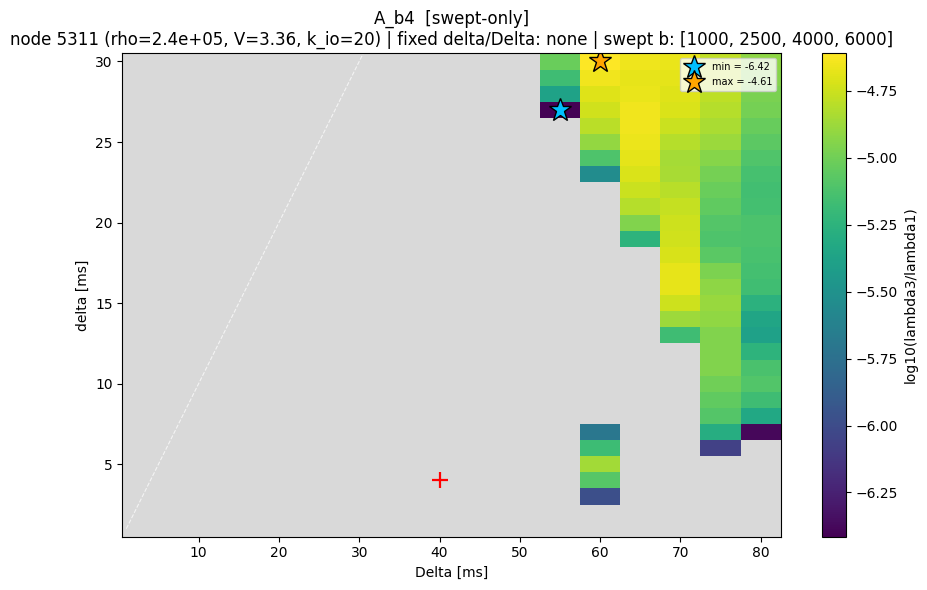

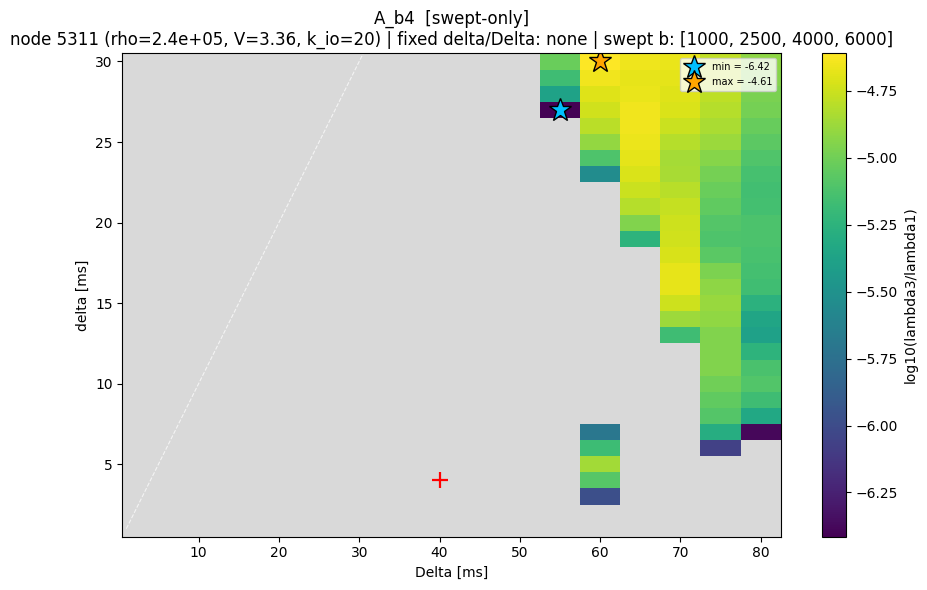

In [27]:
# ---- map A: one swept timing, with named-run comparison ---------------------
# Requires the registry cell above. Each cell of the map is a single timing
# pair carrying HMA_B.
#
# HMA_METRIC picks what gets plotted:
#   "ratio"          lambda3/lambda1 of the k_io-scaled Fisher matrix, (0, 1],
#                     higher = better conditioned. HMA_PARAM is ignored.
#   "crlb"           Cramer-Rao bound of PARAMETER_ORDER[HMA_PARAM], lower =
#                     better (more precise).
#   "relative_crlb"  fractional CRLB of that same parameter, lower = better.
# HMA_PARAM: 0 = log_rho, 1 = log_V, 2 = k_io. Only used for the crlb metrics.
#
# Give the run a name and it goes into HM_RUNS. Point HMA_COMPARE_TO at an
# earlier name to see the change. HMA_COMPARE_TO = None just plots this run.
# ---- parameter coordinate --------------------------------------------------
RHO   = 2.5e5     # cells/uL
V     = 4.0       # pL
K_IO  = 20.0      # 1/s


HMA_RHO, HMA_V, HMA_KIO = RHO, V, K_IO         # parameter coordinate for the map
HMA_B    = [1000, 2500, 4000, 6000]            # b-values at every timing pair

HMA_METRIC = "ratio"                           # "ratio" | "crlb" | "relative_crlb"
HMA_PARAM  = 2                                 # 0=log_rho, 1=log_V, 2=k_io (crlb metrics only)

HMA_NAME       = "A_b4"                        # name this run in HM_RUNS ("" = don't store)
HMA_COMPARE_TO = None                          # e.g. "A_b3" to compare against that run
HMA_CMP_MODE   = "log2ratio"                   # "log2ratio" | "ratio" | "diff"
HMA_PANELS     = True                          # 3 panels (ref, current, change) vs change only

HMA_LOG  = True                                # log10 colour scale on the map panels
HMA_VMIN = None                                # colour limits, only used without a comparison
HMA_VMAX = None
HMA_MARK_ACQ     = True                        # red + at the ACQUISITIONS timings
HMA_MARK_EXTREMA = True                        # star the min and max cell

HMA_NODE = node_at(HMA_RHO, HMA_V, HMA_KIO)

d, D, field, lam, counts = hm_sweep(HMA_NODE, HMA_B, metric=HMA_METRIC, param=HMA_PARAM)
hma = hm_record(HMA_NAME or "(unnamed)", "swept-only", HMA_NODE, HMA_B, [],
                d, D, field, lam, counts, metric=HMA_METRIC, param=HMA_PARAM)

print(hm_describe(hma))
print(f"pairs: {counts[0]} with a finite value, {counts[1]} not positive definite / "
      f"not identifiable, {counts[2]} unavailable")
if counts[0]:
    i_min = np.unravel_index(np.nanargmin(field), field.shape)
    fmax = np.where(np.isfinite(field), field, -np.inf)      # ignore +inf cells for the max
    i_max = np.unravel_index(np.nanargmax(fmax), field.shape)
    print(f"min  {field[i_min]:.4g} at delta={d[i_min[0]]:.1f}, Delta={D[i_min[1]]:.1f} ms")
    print(f"max  {field[i_max]:.4g} at delta={d[i_max[0]]:.1f}, Delta={D[i_max[1]]:.1f} ms")
    print(f"({hma['convention']}: {'higher' if hma['higher_is_better'] else 'lower'} is better)")

hm_store(hma)

marks = [(dd, DD) for dd, DD, _ in ACQUISITIONS] if HMA_MARK_ACQ else []
hm_show(hma, ref=hm_get(HMA_COMPARE_TO) if HMA_COMPARE_TO else None,
        cmp_mode=HMA_CMP_MODE, log=HMA_LOG, vmin=HMA_VMIN, vmax=HMA_VMAX,
        marks=marks, mark_extrema=HMA_MARK_EXTREMA, panels=HMA_PANELS)

## Map B — fixed timings plus one swept timing

Every cell of the map is the joint acquisition of `HMB_FIXED` plus the swept
pair, answering "given what I already measure, what does one more timing buy
me". Can be compared directly against a map-A run as long as both use the
same `..._METRIC` (and `..._PARAM`, for the crlb metrics).

B_fixed20_60_relative_crlb  [fixed+swept]
node 5311 (rho=2.4e+05, V=3.36, k_io=20) | fixed delta/Delta: none | swept b: [1000, 2500, 4000, 6000]
fixed alone: relative CRLB(k_io) = undefined (not positive definite / not identifiable)
pairs: 1245 with a finite value, 0 not positive definite / not identifiable, 0 unavailable
min  8.037 at delta=3.0, Delta=18.0 ms
max  242 at delta=2.0, Delta=6.0 ms
(relative CRLB(k_io): lower is better)
run replaced as 'B_fixed20_60_relative_crlb'  (4 run(s) in HM_RUNS)


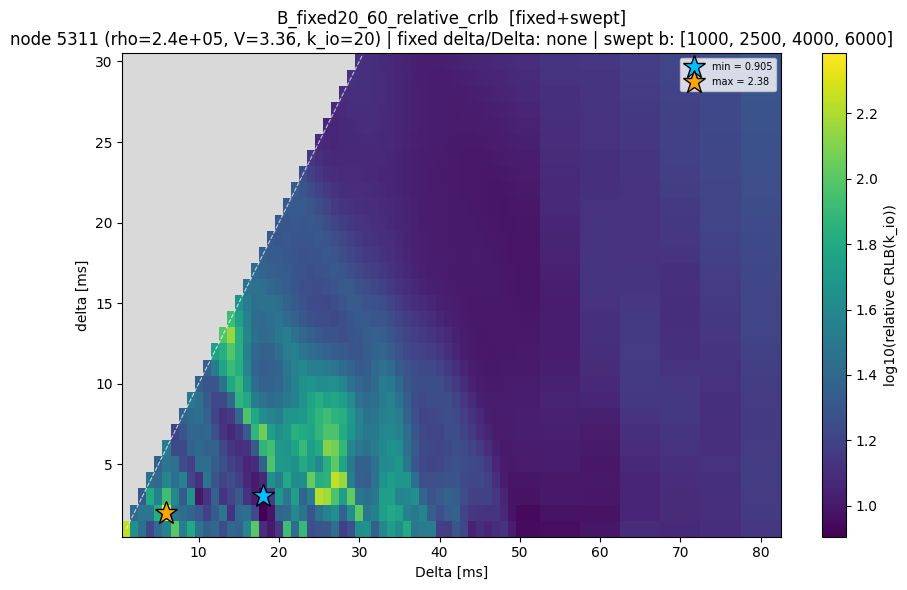

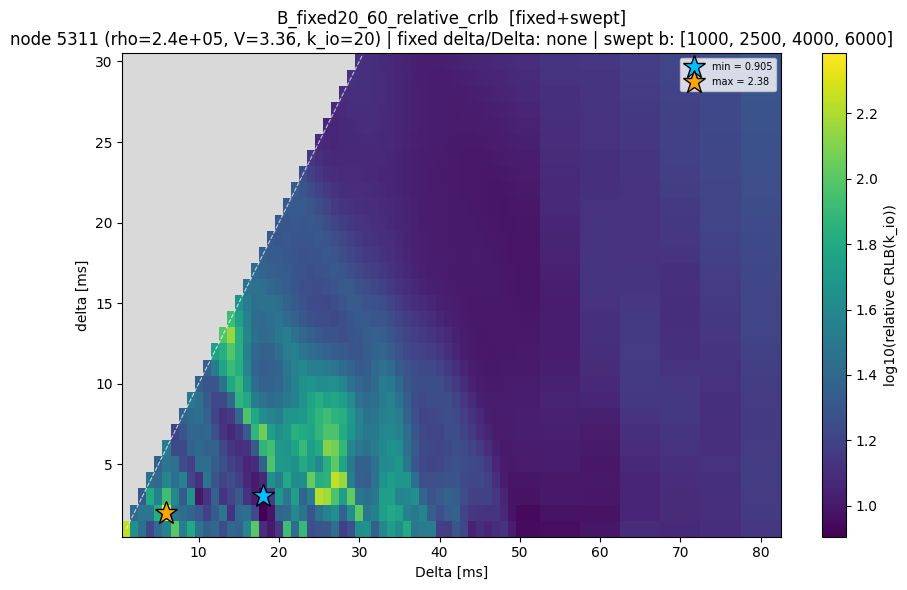

In [32]:
# ---- map B: fixed timings plus one swept timing, with named-run comparison ---
# Requires the registry cell above. Each cell of the map is the joint
# acquisition HMB_FIXED + the swept pair, so it answers "given what I already
# measure, what does one more timing buy me".
#
# HMB_METRIC picks what gets plotted (same three choices as map A):
#   "ratio"          lambda3/lambda1, (0, 1], higher = better. HMB_PARAM ignored.
#   "crlb"           Cramer-Rao bound of PARAMETER_ORDER[HMB_PARAM], lower = better.
#   "relative_crlb"  fractional CRLB of that parameter, lower = better.
# HMB_PARAM: 0 = log_rho, 1 = log_V, 2 = k_io. Only used for the crlb metrics.
#
# Give the run a name and it goes into the same HM_RUNS as map A, so a
# fixed+swept run can be compared against a swept-only run directly -- as long
# as both use the same metric (and same param, for the crlb metrics).

# HMB_RHO, HMB_V, HMB_KIO = RHO, V, K_IO         # parameter coordinate for the map
HMB_rho, HMB_V, HMB_KIO = 2.5e5, 4.0, 20.0         # parameter coordinate for the map

DEBIAS=False
# Fixed columns. Each row is (delta [ms], Delta [ms], [b-values]); rows may use
# different b-value lists. Add as many rows as you like.
HMB_FIXED = [
    # (4.0, 20.0, [1000, 2500, 4000, 6000]),
    # (4.0, 40.0, [1000, 2500, 4000, 6000]),
    # (4.0, 60.0, [1000, 2500, 4000, 6000]),
]
HMB_B     = [1000, 2500, 4000, 6000]           # b-values carried by the swept pair

HMB_METRIC = "relative_crlb"                           # "ratio" | "crlb" | "relative_crlb"
HMB_PARAM  = 2                                # 0=log_rho, 1=log_V, 2=k_io (crlb metrics only)

HMB_NAME       = "B_fixed20_60_relative_crlb"                # name this run in HM_RUNS ("" = don't store)
HMB_COMPARE_TO = None                          # e.g. "A_b4" or an earlier B run
HMB_CMP_MODE   = "log2ratio"                   # "log2ratio" | "ratio" | "diff"
HMB_PANELS     = True                          # 3 panels (ref, current, change) vs change only

HMB_NORM = False                               # True: divide the map by the fixed-only value
HMB_LOG  = True                                # log10 colour scale on the map panels
HMB_VMIN = None                                # colour limits, only used without a comparison
HMB_VMAX = None
HMB_MARK_EXTREMA = True                        # star the min and max cell

HMB_NODE = node_at(HMB_RHO, HMB_V, HMB_KIO)

# Fixed columns on their own, as the baseline the map is read against.
try:
    _r = analyze_acquisition(HMB_NODE, list(HMB_FIXED), averages=AVERAGES, snr=SNR,
                             T2=T2_MS, t_epi=T_EPI_MS, trust_floor=0.0, rician_min=0.0,
                             debias=DEBIAS, n0_eff=N0_EFF, g_max=np.inf, drop_b0=DROP_B0)
    hmb_base, _base_ok = hm_field_value(_r, HMB_METRIC, HMB_PARAM)
    if not _base_ok:
        hmb_base = np.nan                      # inf isn't a usable normalisation base either
except ValueError:
    hmb_base = np.nan

d, D, field, lam, counts = hm_sweep(HMB_NODE, HMB_B, fixed=HMB_FIXED,
                                    metric=HMB_METRIC, param=HMB_PARAM)

if HMB_NORM:
    if not np.isfinite(hmb_base):
        raise ValueError("HMB_NORM needs a finite fixed-only value; the fixed columns "
                         "alone are not positive definite / not identifiable here")
    field = field / hmb_base                   # 1 = the swept pair changed nothing

hmb = hm_record(HMB_NAME or "(unnamed)", "fixed+swept", HMB_NODE, HMB_B, HMB_FIXED,
                d, D, field, lam, counts, metric=HMB_METRIC, param=HMB_PARAM)
if HMB_NORM:                                   # keep the registry honest about units
    hmb["convention"] = f"({hmb['convention']}) / fixed-only"
    # dividing by a positive constant doesn't flip which direction is better

print(hm_describe(hmb))
print(f"fixed alone: {hmb['convention'] if not HMB_NORM else hm_metric_label(HMB_METRIC, HMB_PARAM)[0]} = "
      + (f"{hmb_base:.6g}" if np.isfinite(hmb_base) else "undefined (not positive definite / not identifiable)"))
print(f"pairs: {counts[0]} with a finite value, {counts[1]} not positive definite / "
      f"not identifiable, {counts[2]} unavailable")
if counts[0]:
    i_min = np.unravel_index(np.nanargmin(field), field.shape)
    fmax = np.where(np.isfinite(field), field, -np.inf)      # ignore +inf cells for the max
    i_max = np.unravel_index(np.nanargmax(fmax), field.shape)
    print(f"min  {field[i_min]:.4g} at delta={d[i_min[0]]:.1f}, Delta={D[i_min[1]]:.1f} ms")
    print(f"max  {field[i_max]:.4g} at delta={d[i_max[0]]:.1f}, Delta={D[i_max[1]]:.1f} ms")
    print(f"({hmb['convention']}: {'higher' if hmb['higher_is_better'] else 'lower'} is better)")
    if np.isfinite(hmb_base) and not HMB_NORM:
        print(f"relative to fixed alone: min cell = {field[i_min] / hmb_base:.3g}x, "
              f"max cell = {field[i_max] / hmb_base:.3g}x")

hm_store(hmb)

hm_show(hmb, ref=hm_get(HMB_COMPARE_TO) if HMB_COMPARE_TO else None,
        cmp_mode=HMB_CMP_MODE, log=HMB_LOG, vmin=HMB_VMIN, vmax=HMB_VMAX,
        marks=[(dd, DD) for dd, DD, _ in HMB_FIXED],
        mark_extrema=HMB_MARK_EXTREMA, panels=HMB_PANELS)